# OmniAI OCR Benchmark: exploratory data analysis
**Anh Hoang · Legal 2A**

This notebook reconstructs the analysis behind the [EDA slides](https://docs.google.com/presentation/d/1poqPSpqKBoqeF1zeKsCgTUHHwf5Bc_CeOHXyzRG84OU/edit).
Run the cells in order to inspect class balance, document examples, and visual similarity.
All tables and similarity scores below are computed from the loaded dataset, not copied from the slides.

The dataset is `getomni-ai/ocr-benchmark`, supplied as a `test` split. This is exploratory analysis of that split, not a held-out model evaluation. No classifier is trained here.

## 1. Setup and dataset
Use a Python kernel with the packages below installed. If imports fail, uncomment and run the installation cell, then restart the kernel.
The first run may download the dataset and pretrained ResNet-18 weights. Later runs use the normal Hugging Face and PyTorch caches.

In [1]:
# %pip install datasets pandas pillow numpy matplotlib torch torchvision tqdm

In [2]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torchvision

from datasets import load_dataset
from IPython.display import display
from PIL import ImageOps
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

SEED = 42
HEAD_CLASS_MIN_COUNT = 30  # Descriptive grouping, not a learned decision boundary.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, torch.get_num_threads()))
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

ds = load_dataset("getomni-ai/ocr-benchmark", split="test")
print(ds)
print("Dataset fingerprint:", ds._fingerprint)
print("PyTorch:", torch.__version__, "Torchvision:", torchvision.__version__)
display(ds.features)

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Dataset({
    features: ['id', 'metadata', 'json_schema', 'true_json_output', 'true_markdown_output', 'image'],
    num_rows: 1000
})
Dataset fingerprint: afd9e972c6a10e91
PyTorch: 2.9.1+cpu Torchvision: 0.24.1+cpu


{'id': Value('int64'),
 'metadata': Value('string'),
 'json_schema': Value('string'),
 'true_json_output': Value('string'),
 'true_markdown_output': Value('string'),
 'image': Image(mode=None, decode=True)}

## 2. Labels, class balance, and document quality
`metadata` is a JSON string. Normalize whitespace and case before counting labels; otherwise `SCANNED_TABLE ` can become a separate class.
"Common" means at least 30 examples here. "Rare" means fewer than 30; neither label describes visual diversity or whether the class is unknown.

1,000 documents, 36 normalized format labels


,group,classes,documents,share_percent
0,Common,18,925,92.5
1,Rare,18,75,7.5


,samples
format,
REAL_ESTATE,59
PATIENT_INTAKE,53
SHIPPING_INVOICE,52
COMMERCIAL_LEASE_AGREEMENT,52
BANK_CHECK,52
ACCOUNT_STATEMENT,52
PATENT,52
SHIFT_SCHEDULE,52
DELIVERY_NOTE,51


Singleton classes: CAPTCHA, PHOTO_DOC, SIGNATURE, DIAGRAM


,samples
document_quality,
CLEAN,338
HIGH_QUALITY,303
LOW_QUALITY,259
PHOTO,100


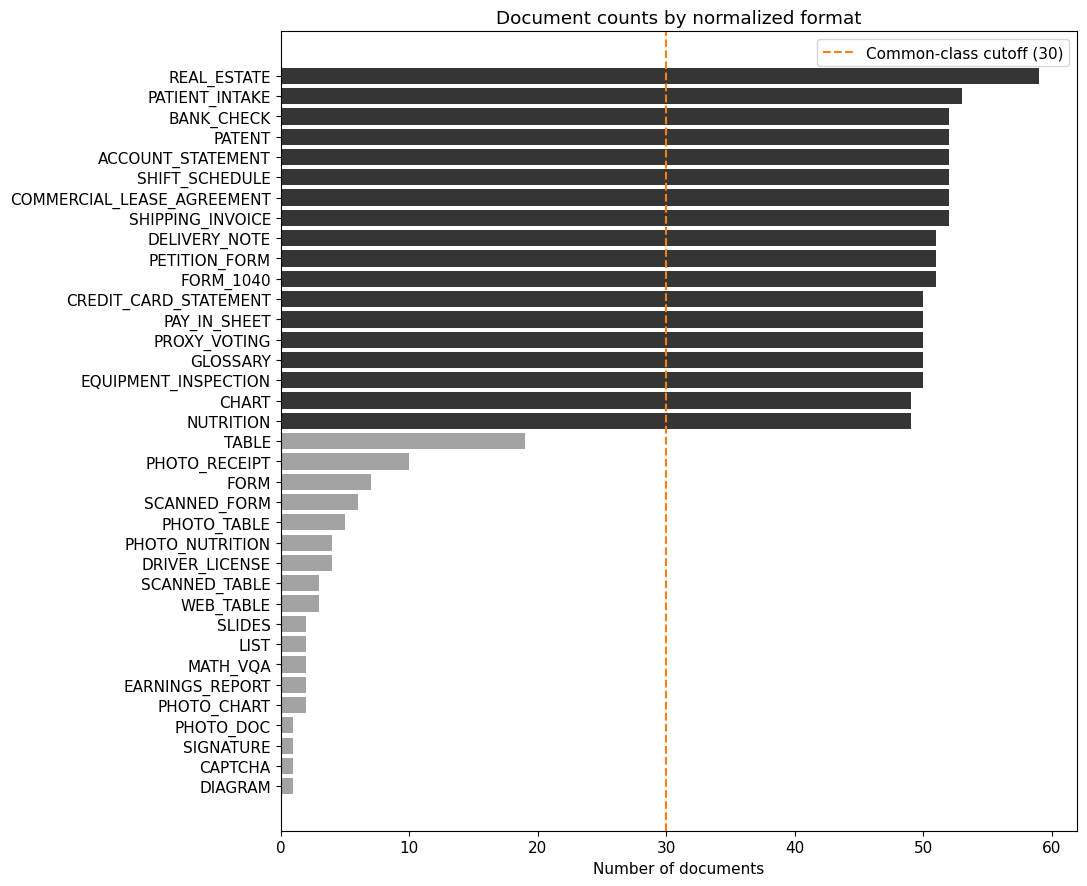

In [3]:
metadata = [json.loads(value) for value in ds["metadata"]]
df = pd.DataFrame({
    "id": list(ds["id"]),
    "format": [meta.get("format", "").strip().upper() for meta in metadata],
    "document_quality": [meta.get("documentQuality", "").strip().upper() for meta in metadata],
})
assert df["id"].is_unique, "Document IDs must identify individual rows."
assert df["format"].ne("").all(), "Inspect records with missing format labels."

counts = df["format"].value_counts()
head = counts[counts >= HEAD_CLASS_MIN_COUNT]
tail = counts[counts < HEAD_CLASS_MIN_COUNT]
print(f"{len(df):,} documents, {len(counts)} normalized format labels")
balance = pd.DataFrame([
    {"group": "Common", "classes": len(head), "documents": int(head.sum())},
    {"group": "Rare", "classes": len(tail), "documents": int(tail.sum())},
])
balance["share_percent"] = balance["documents"] / len(df) * 100
display(balance)
with pd.option_context("display.max_rows", None):
    display(counts.rename("samples").to_frame())
print("Singleton classes:", ", ".join(counts[counts == 1].index))
display(df["document_quality"].value_counts(dropna=False).rename("samples").to_frame())

fig, ax = plt.subplots(figsize=(11, 9))
ordered = counts.sort_values()
ax.barh(ordered.index, ordered.values,
        color=["#353535" if n >= HEAD_CLASS_MIN_COUNT else "#a3a3a3" for n in ordered])
ax.set(xlabel="Number of documents", title="Document counts by normalized format")
ax.axvline(HEAD_CLASS_MIN_COUNT, color="tab:orange", linestyle="--", label="Common-class cutoff (30)")
ax.legend()
fig.tight_layout()
plt.show()

### Interpretation
The slide snapshot contained 1,000 documents and 36 normalized formats: 18 common classes held 925 documents (92.5%), while 18 rare classes shared 75 (7.5%). Compare those historical totals with the computed table above.

The labels mix document purpose (`COMMERCIAL_LEASE_AGREEMENT`), structure (`TABLE`), and capture method (`PHOTO_TABLE`, `SCANNED_TABLE`). Define the project's target labels and legal scope before training.
Singleton classes cannot appear in every partition of a conventional train/validation/test split.

## 3. Inspect one document and its annotations
The dataset pairs an image with a document-specific JSON schema, structured reference output, and reference transcription. These annotations are ground truth, not predictions.

Document ID: 5
Metadata: {
  "format": "TABLE",
  "documentQuality": "PHOTO"
}
JSON schema: {"type":"object","properties":{"total":{"type":"number","description":"In thousands"},"subtotal":{"type":"number","description":"In thousands"},"inflation":{"type":"object","properties":{"rate":{"type":"number"},"amount":{"type":"number","description":"In percentage"},"duration":{"type":"number","description":"In years"}}},"major_equipment_needs":{"type":"array","items":{"type":"object","properties":{"no":{"type":"number"},"item":{"type":"string"},"unit_cost":{"type":"number","description":"In thousands"},"extended_cost":{"type":"number","description":"In thousands"}},"description":""}}}}
Structured reference:
{
  "total": 467.5,
  "subtotal": 353.5,
  "inflation": {
    "rate": 15,
    "amount": 114,
    "duration": 2
  },
  "major_equipment_needs": [
    {
      "no": 1,
      "item": "Atomic Absorption Spectrometer",
      "unit_cost": 17,
      "extended_cost": 17
    },
    {
      "no": 36

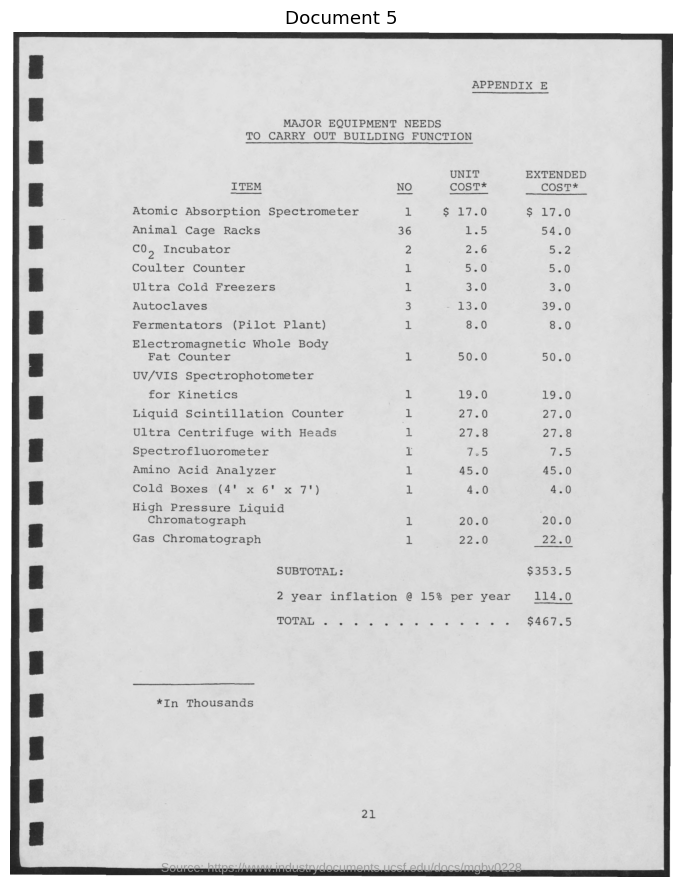

In [4]:
example_position = 5
example = ds[example_position]
print("Document ID:", example["id"])
print("Metadata:", json.dumps(metadata[example_position], indent=2))
print("JSON schema:", example["json_schema"])
print("Structured reference:")
print(json.dumps(json.loads(example["true_json_output"]), indent=2, ensure_ascii=False))
fig, ax = plt.subplots(figsize=(7, 9))
ax.imshow(example["image"].convert("RGB"))
ax.set_title(f"Document {example['id']}")
ax.axis("off")
fig.tight_layout()
plt.show()

## 4. Secondary features
Record image dimensions, aspect ratio, and reference-text length for descriptive analysis. Some reference transcriptions are JSON-encoded strings, so decode them before counting characters.
Reference-text length must not become an input to an image-only model. These summaries do not measure OCR accuracy or explain model errors.

In [5]:
def decode_reference_text(value):
    text = value or ""
    try:
        decoded = json.loads(text)
        if isinstance(decoded, str):
            return decoded
    except (ValueError, TypeError):
        pass
    return text

rows = []
for position, record in enumerate(tqdm(ds, desc="Image and text features")):
    width, height = record["image"].size
    rows.append({
        "id": record["id"],
        "format": df.iloc[position]["format"],
        "quality": df.iloc[position]["document_quality"],
        "width": width,
        "height": height,
        "megapixels": width * height / 1_000_000,
        "aspect_ratio": width / height,
        "text_characters": len(decode_reference_text(record["true_markdown_output"])),
    })
features = pd.DataFrame(rows)
display(features.head())
display(features[["width", "height", "megapixels", "aspect_ratio", "text_characters"]].describe())

Image and text features:   0%|          | 0/1000 [00:00<?, ?it/s]

,id,format,quality,width,height,megapixels,aspect_ratio,text_characters
0,0,TABLE,PHOTO,1009,417,0.420753,2.419664,645
1,1,CHART,CLEAN,1414,1816,2.567824,0.778634,1679
2,2,CHART,CLEAN,1490,1916,2.854840,0.777662,3640
3,3,TABLE,PHOTO,730,765,0.558450,0.954248,924
4,4,TABLE,PHOTO,486,396,0.192456,1.227273,3525


,width,height,megapixels,aspect_ratio,text_characters
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1942.186000,2029.645000,4.158386,1.097785,4286.097000
std,663.582428,818.216043,2.884432,0.633470,3798.433467
min,160.000000,56.000000,0.009600,0.177931,4.000000
25%,1684.750000,1571.750000,2.792272,0.754000,1721.000000
50%,1904.000000,2014.500000,3.749543,0.905705,3079.500000
75%,2168.000000,2461.750000,4.950400,1.226921,5356.000000
max,6906.000000,7016.000000,34.806376,8.678571,24428.000000


## 5. Within-class sample grids
These reproduce the classes illustrated in the slides: commercial leases, shipping invoices, and photographed receipts. Sampling uses a fixed seed without replacement.
Inspect layout, filled values, capture quality, and orientation separately. A six-image grid is an illustration, not evidence that every member of a class shares one template.

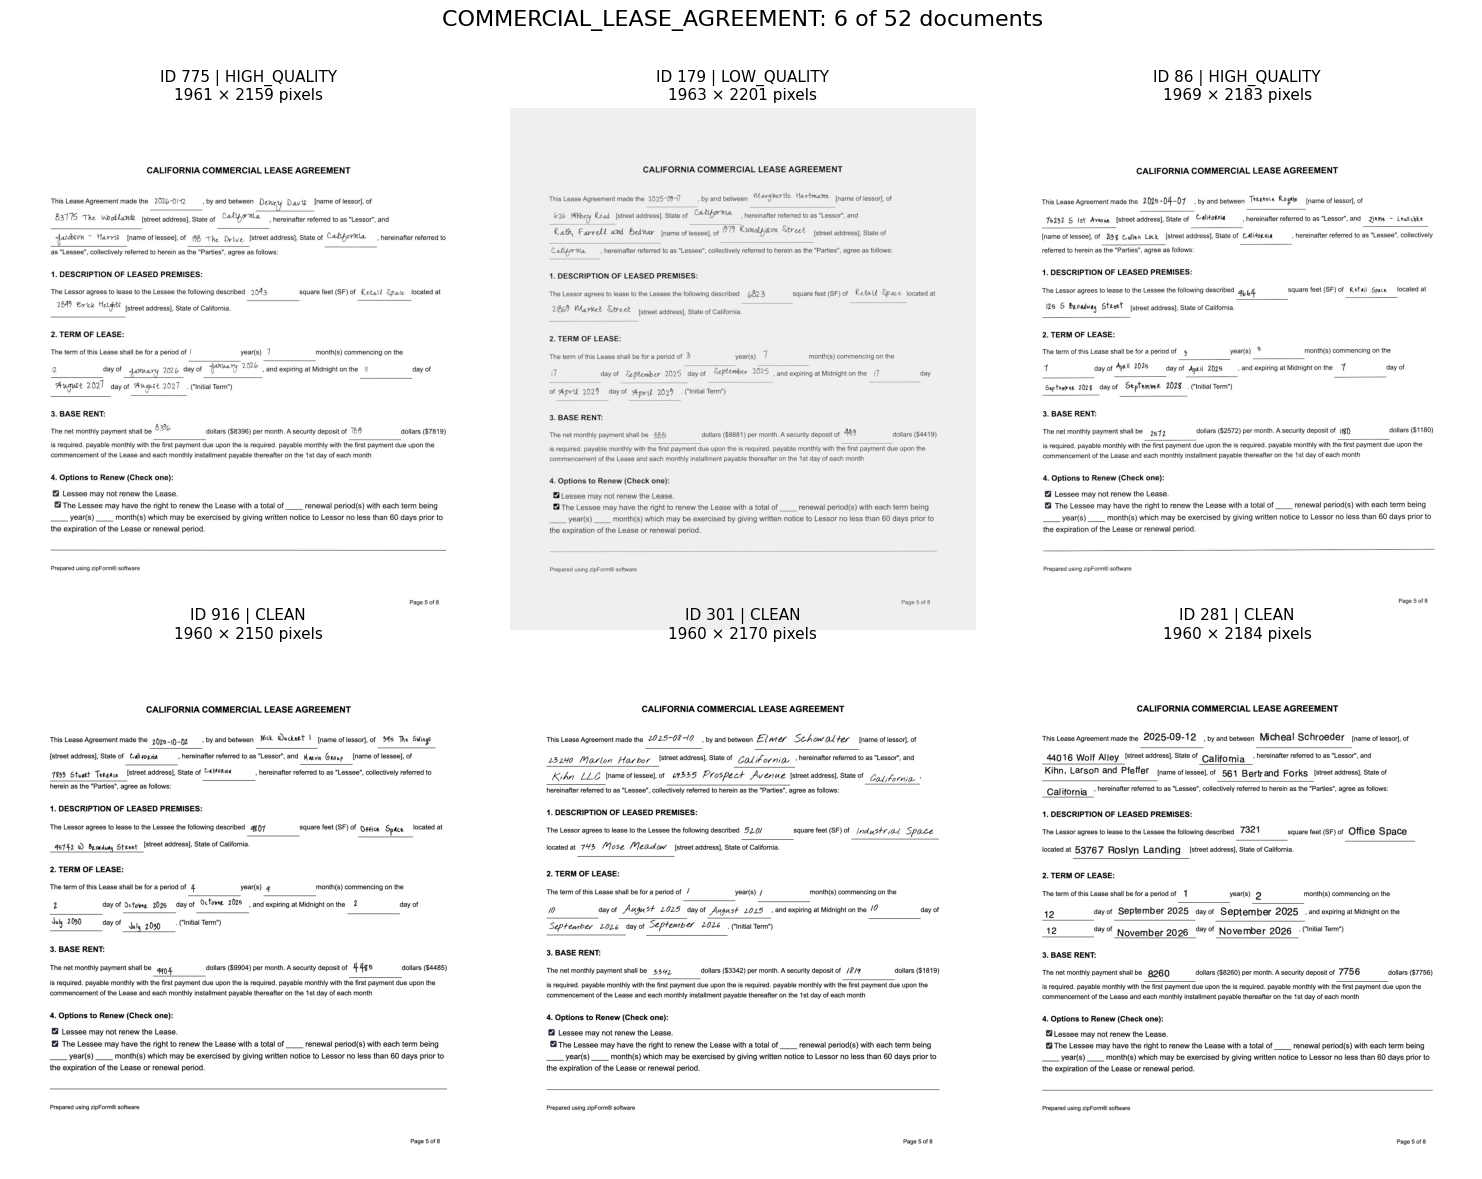

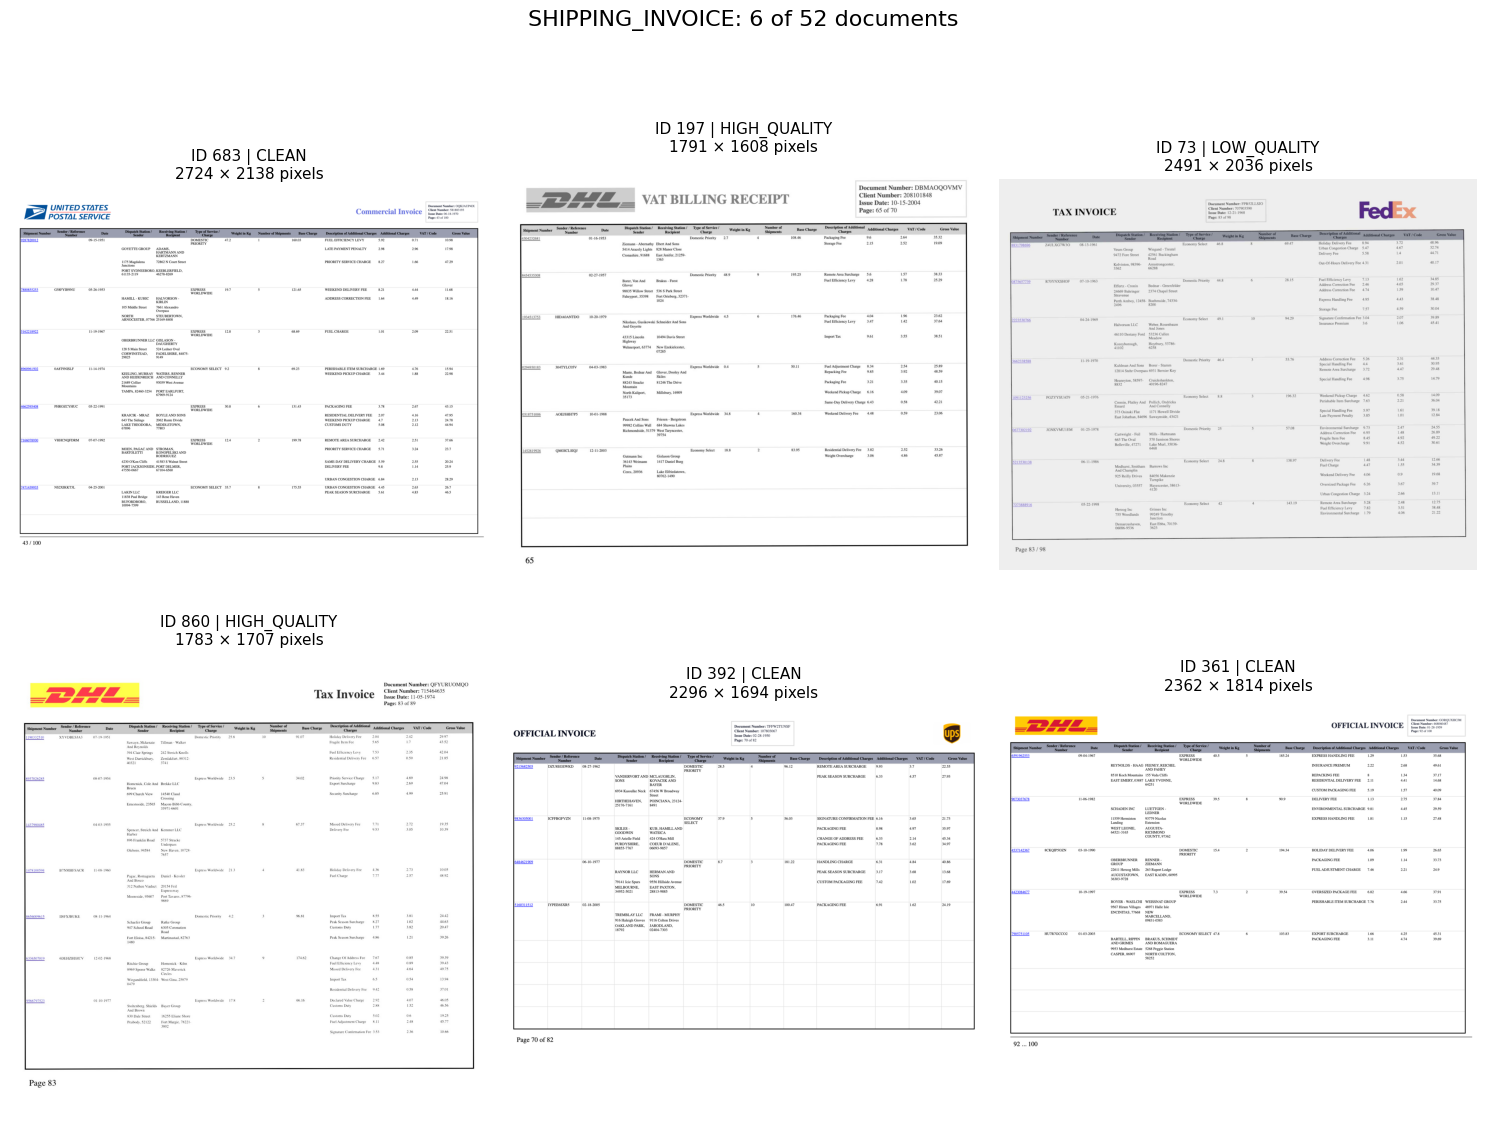

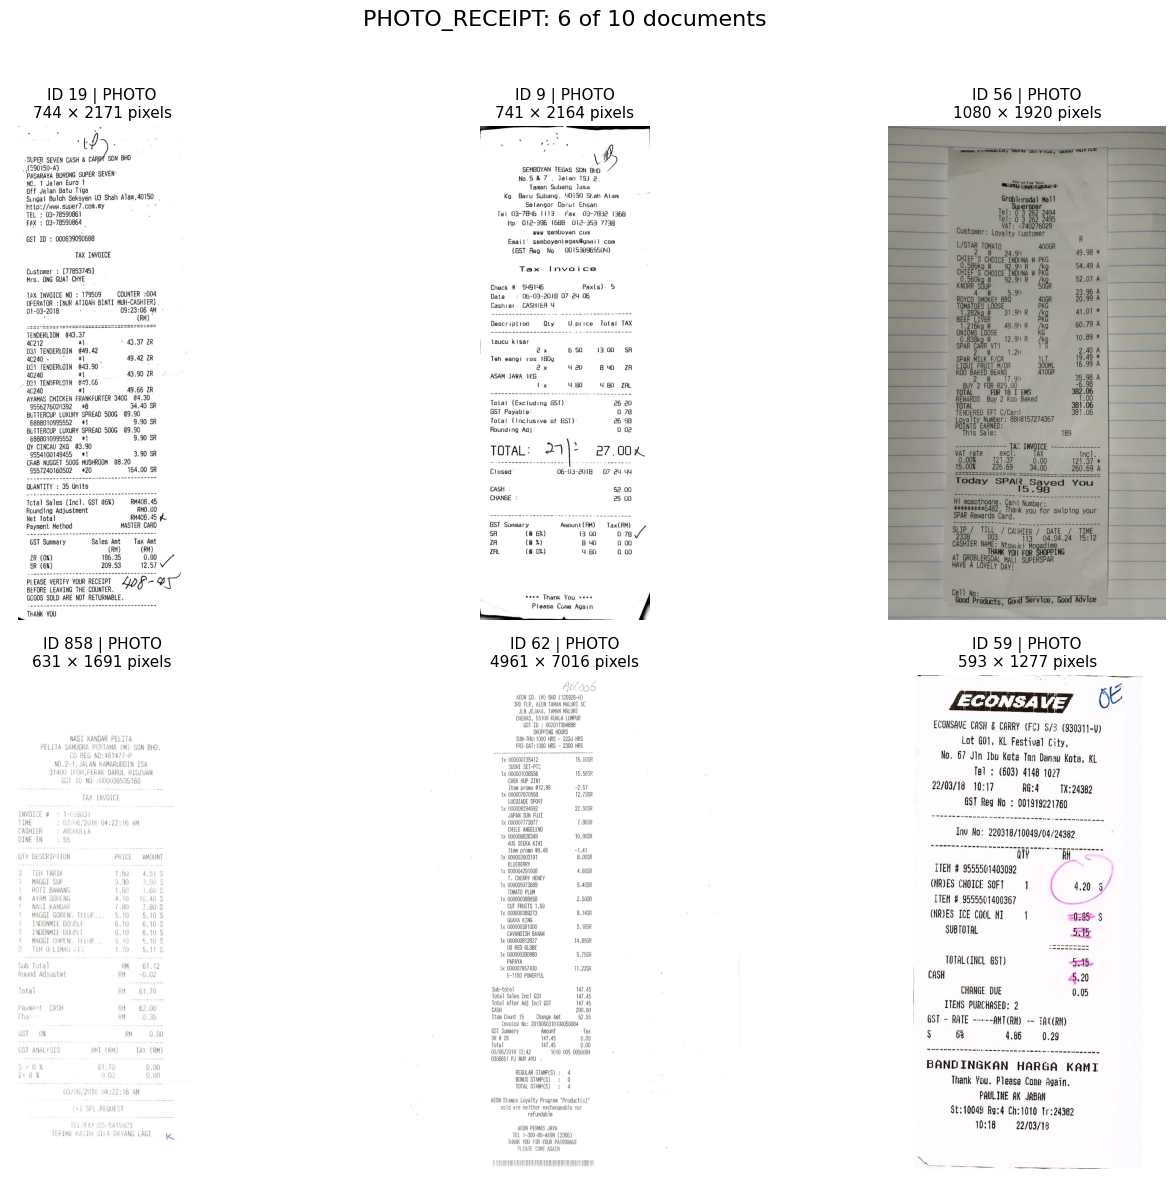

In [6]:
def show_samples(target_class, sample_size=6, seed=SEED):
    positions = df.index[df["format"] == target_class].tolist()
    if not positions:
        raise ValueError(f"No documents with format {target_class!r}")
    if sample_size < 1:
        raise ValueError("sample_size must be positive")
    selected = random.Random(seed).sample(positions, min(sample_size, len(positions)))
    columns = min(3, len(selected))
    rows = (len(selected) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(15, 6 * rows), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, position in zip(axes.flat, selected):
        record = ds[position]
        image = record["image"].convert("RGB")
        quality = df.iloc[position]["document_quality"]
        ax.imshow(image)
        ax.set_title(f"ID {record['id']} | {quality}\n{image.width} × {image.height} pixels", fontsize=11)
    fig.suptitle(f"{target_class}: {len(selected)} of {len(positions)} documents", fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()
    return selected

for target_class in ["COMMERCIAL_LEASE_AGREEMENT", "SHIPPING_INVOICE", "PHOTO_RECEIPT"]:
    show_samples(target_class)

## 6. Image embeddings with pretrained ResNet-18
Match the slide method: ImageNet-pretrained ResNet-18, classification layer removed, RGB images padded to 224 × 224, and 512-dimensional vectors normalized to unit length.
The dot product of normalized vectors is cosine similarity. This measures resemblance under this visual representation; it is not classification accuracy, a duplicate probability, or proof of matching text.
Small text details can disappear at this resolution. No model fitting or fine-tuning occurs here.

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights)
model.fc = torch.nn.Identity()
model = model.to(device).eval()
preprocess = weights.transforms(resize_size=224, crop_size=224)
batch_size = 16
batches = []

with torch.inference_mode():
    for start in tqdm(range(0, len(ds), batch_size), desc=f"ResNet-18 embeddings ({device})"):
        images = []
        for position in range(start, min(start + batch_size, len(ds))):
            image = ds[position]["image"].convert("RGB")
            image = ImageOps.pad(image, (224, 224), color="white")
            images.append(preprocess(image))
        batch = torch.stack(images).to(device)
        batches.append(F.normalize(model(batch), dim=1).cpu())

embeddings = torch.cat(batches)
formats = df["format"].tolist()
assert embeddings.shape == (len(ds), 512)
assert torch.isfinite(embeddings).all()
assert torch.allclose(embeddings.norm(dim=1), torch.ones(len(ds)), atol=1e-5)
print("Embedding shape:", tuple(embeddings.shape))

ResNet-18 embeddings (cpu):   0%|          | 0/63 [00:00<?, ?it/s]

Embedding shape: (1000, 512)


## 7. Similarity within and between classes
Compare each within-class pair once, excluding self-comparisons. Report class size and pair count alongside the mean.
A class with two documents has only one pair; a singleton has no pair and receives `NaN`, not zero. Pairs sharing a document are not independent observations.
The between-class baseline pools all cross-class document pairs, so larger classes contribute more pairs. It is context for these scores, not an UNKNOWN threshold.

In [8]:
all_similarities = embeddings @ embeddings.T
labels = pd.Series(formats, name="format")
results = []
for format_name, group in labels.groupby(labels):
    positions = torch.tensor(group.index.to_numpy())
    n = len(positions)
    pairs = torch.triu_indices(n, n, offset=1)
    similarities = all_similarities[positions[:, None], positions[None, :]]
    values = similarities[pairs[0], pairs[1]]
    results.append({
        "format": format_name,
        "similarity": values.mean().item() if n >= 2 else float("nan"),
        "sample": n,
        "pairs": n * (n - 1) // 2,
        "frequency": "Common" if n >= HEAD_CLASS_MIN_COUNT else "Rare",
    })
result = pd.DataFrame(results).sort_values("similarity", ascending=False).reset_index(drop=True)
with pd.option_context("display.max_rows", None):
    display(result.round(4))

codes = torch.tensor(pd.factorize(labels)[0])
different_format = codes[:, None] != codes[None, :]
cross_pairs = torch.triu(different_format, diagonal=1)
between_class_similarity = all_similarities[cross_pairs].mean().item()
print(f"Average similarity between different formats: {between_class_similarity:.4f}")
print(f"Unique cross-class pairs: {int(cross_pairs.sum()):,}")

,format,similarity,sample,pairs,frequency
0,COMMERCIAL_LEASE_AGREEMENT,0.9429,52,1326,Common
1,PETITION_FORM,0.9396,51,1275,Common
2,FORM_1040,0.9377,51,1275,Common
3,PROXY_VOTING,0.9244,50,1225,Common
4,PATENT,0.9174,52,1326,Common
5,SCANNED_FORM,0.8961,6,15,Rare
6,PAY_IN_SHEET,0.8919,50,1225,Common
7,SHIPPING_INVOICE,0.8885,52,1326,Common
8,DELIVERY_NOTE,0.8820,51,1275,Common
9,REAL_ESTATE,0.8771,59,1711,Common


Average similarity between different formats: 0.7594
Unique cross-class pairs: 475,868


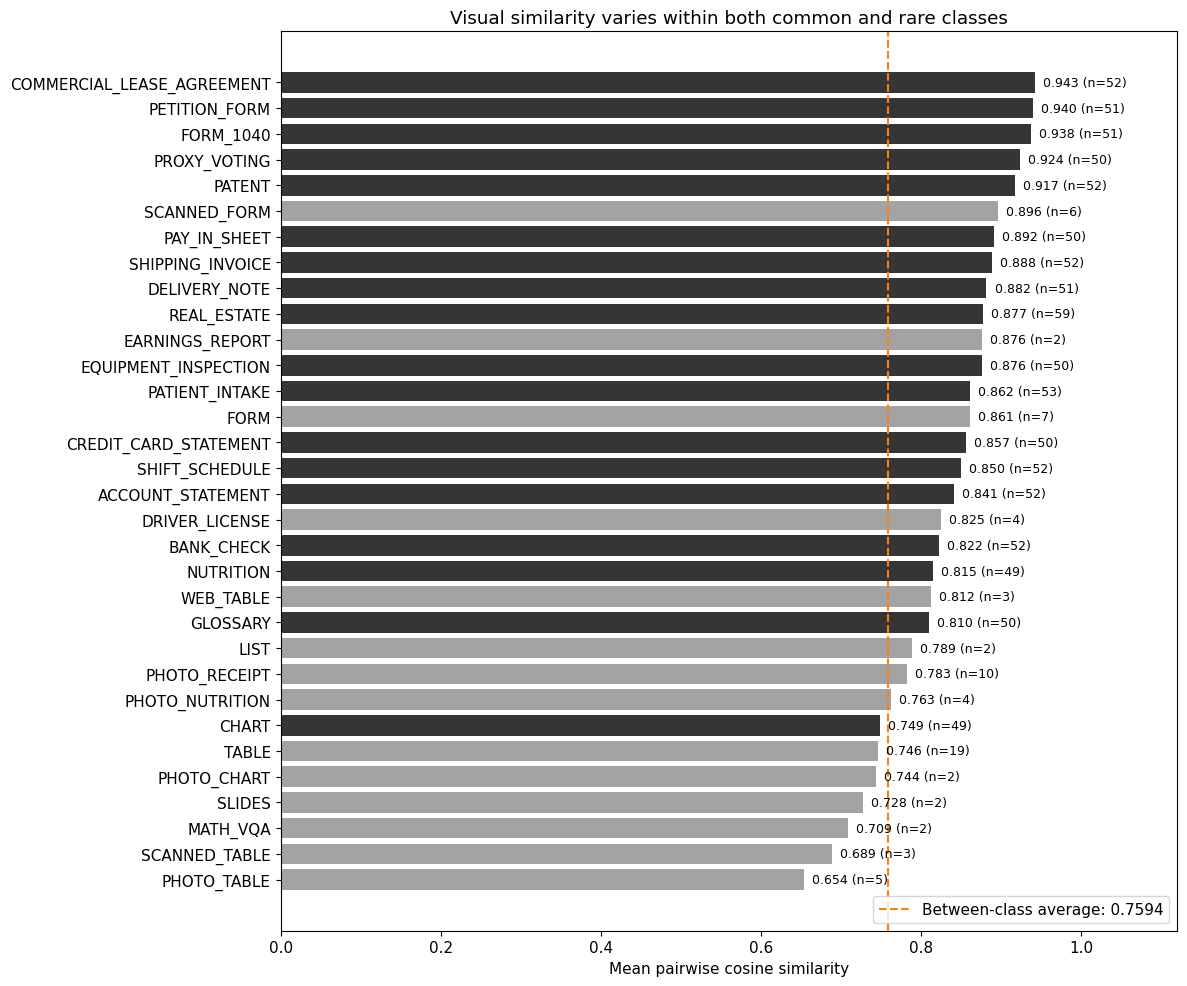

In [9]:
plot_data = result.dropna(subset=["similarity"]).sort_values("similarity")
fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(plot_data["format"], plot_data["similarity"],
        color=["#353535" if group == "Common" else "#a3a3a3" for group in plot_data["frequency"]])
ax.axvline(between_class_similarity, color="tab:orange", linestyle="--",
           label=f"Between-class average: {between_class_similarity:.4f}")
ax.set(xlim=(0, 1.12), xlabel="Mean pairwise cosine similarity",
       title="Visual similarity varies within both common and rare classes")
for y, row in enumerate(plot_data.itertuples()):
    ax.text(row.similarity + 0.01, y, f"{row.similarity:.3f} (n={row.sample})", va="center", fontsize=9)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

### What the similarity scores support
The original slide analysis reported 0.9429 for commercial leases and a 0.7594 between-class baseline. Check the newly computed scores above when rerunning with different package versions or dataset revisions.

Class size and visual diversity are separate questions: `CHART` had 49 examples and mean similarity 0.7486, while `SCANNED_FORM` had six and mean similarity 0.8961. A high score for a two-document class is based on only one pair.
Shared layouts can contain different filled values, so easy form recognition does not establish easy field extraction. These results motivate checking template overlap before splitting data; they do not prove leakage or exact duplicates.

## 8. Reproduce the slide pairs
Use explicit document IDs to reproduce the four pairs shown in the slides. IDs are mapped to row positions rather than assumed to equal them.
Change the IDs to inspect another pair, or omit them to sample two documents using the fixed seed.

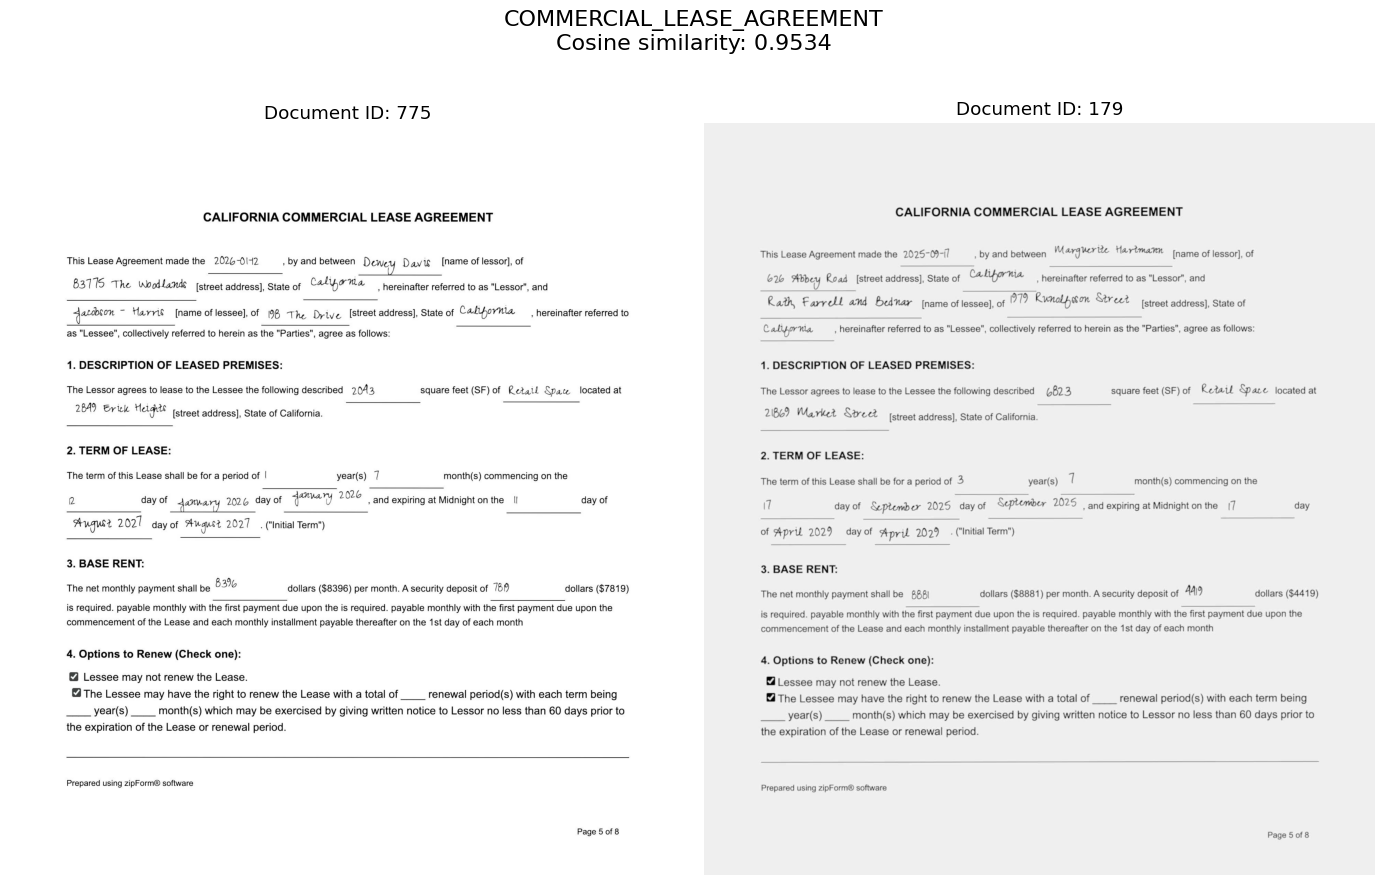

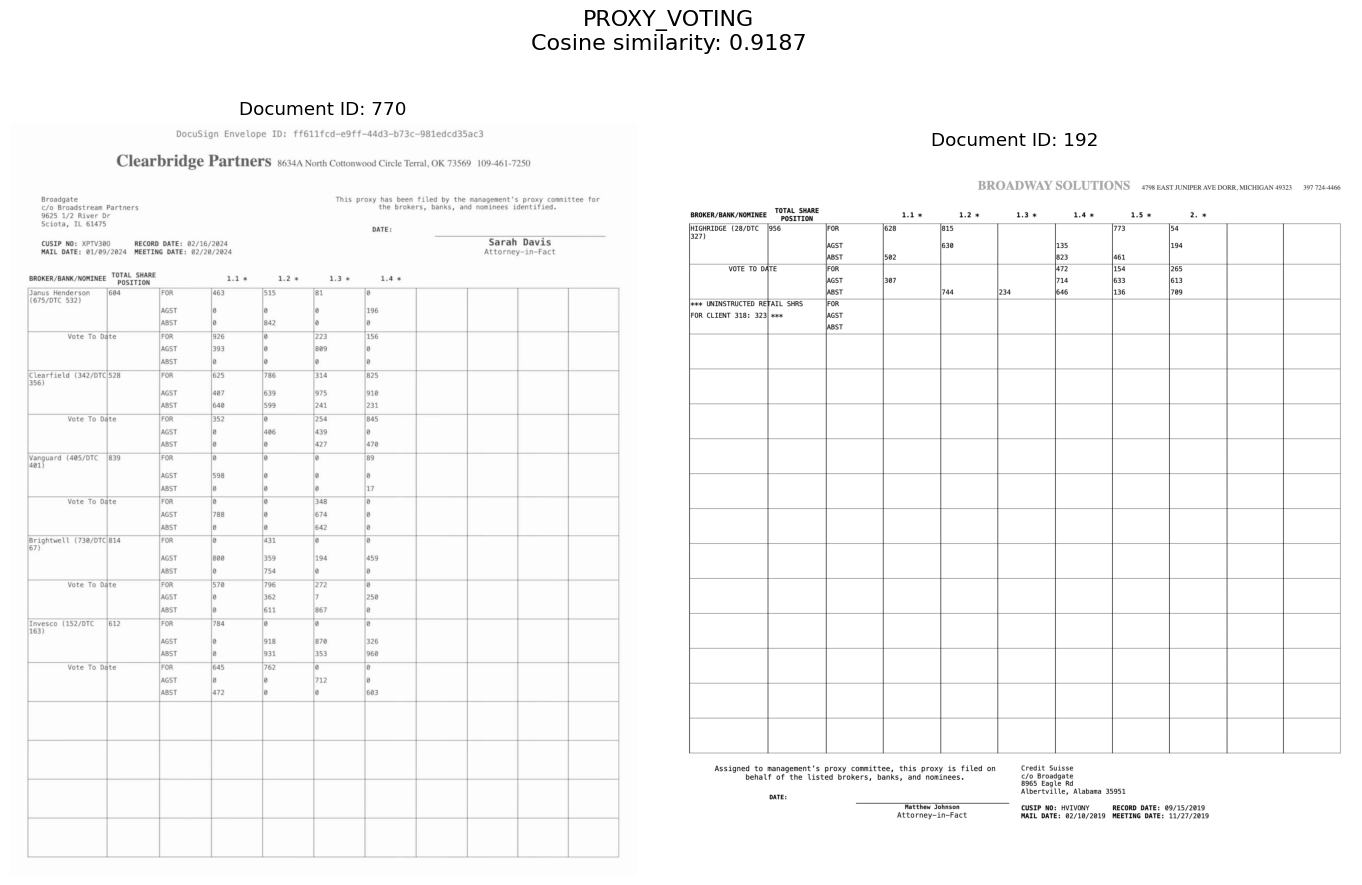

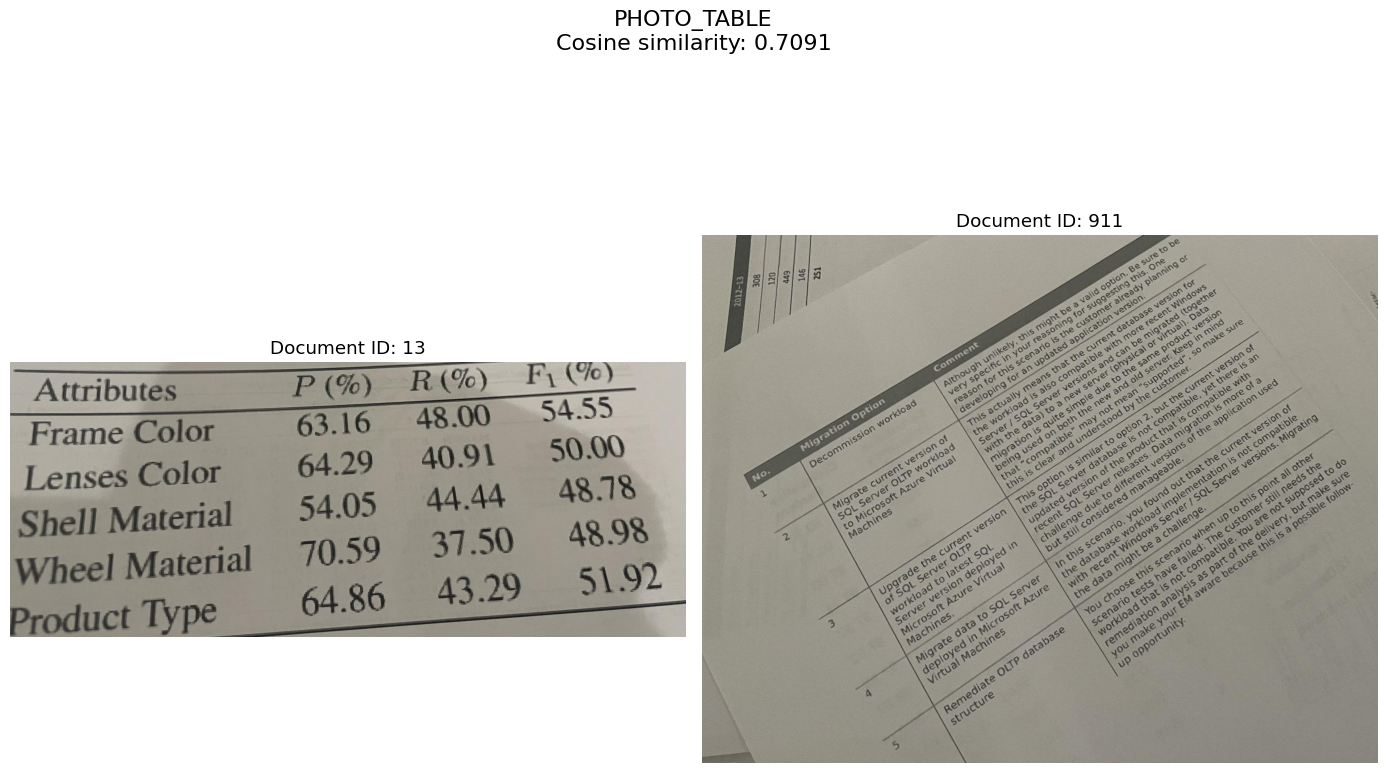

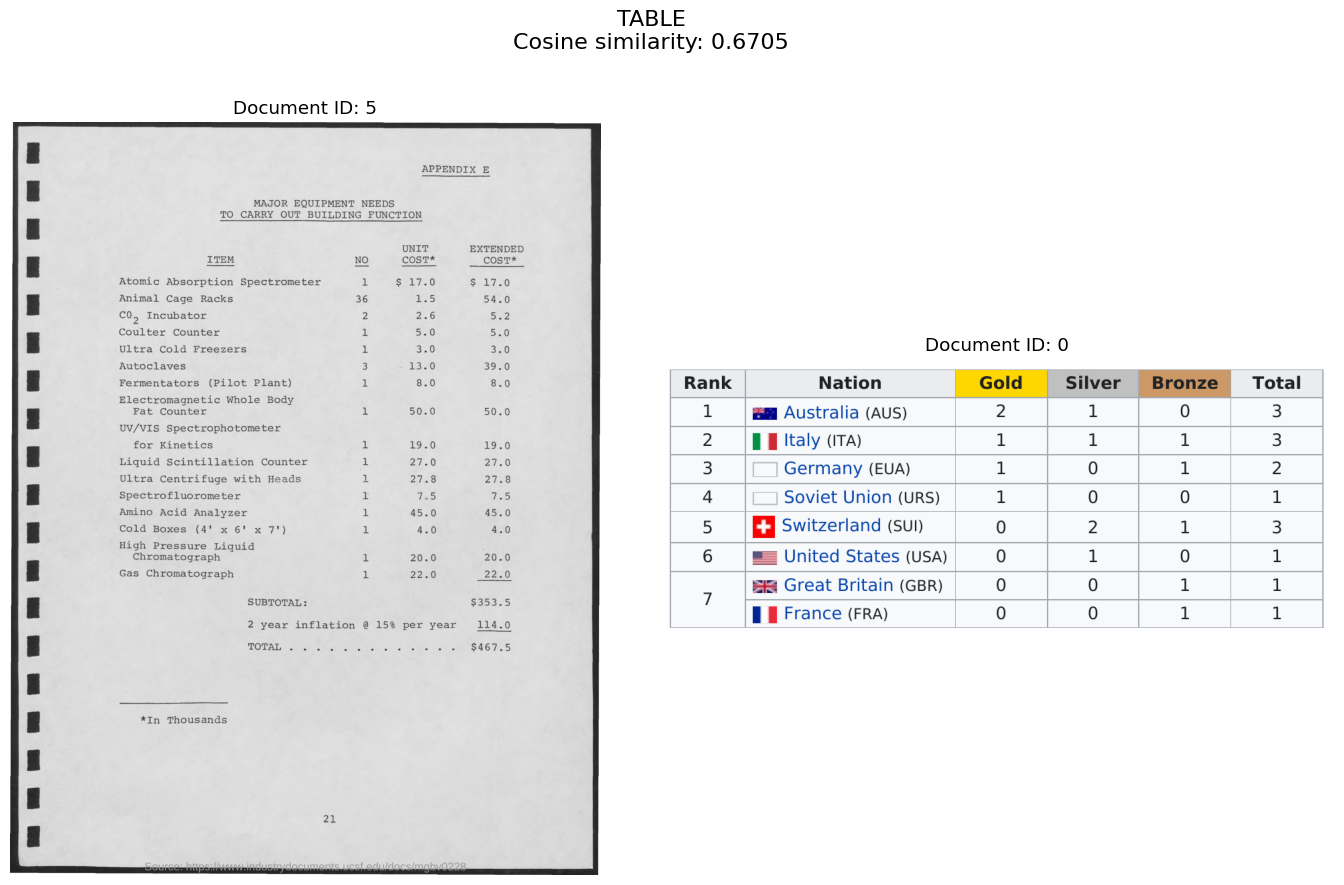

,format,document_ids,similarity
0,COMMERCIAL_LEASE_AGREEMENT,"(775, 179)",0.9534
1,PROXY_VOTING,"(770, 192)",0.9187
2,PHOTO_TABLE,"(13, 911)",0.7091
3,TABLE,"(5, 0)",0.6705


In [10]:
id_to_position = dict(zip(df["id"], df.index))

def show_pair(target_class, document_ids=None, seed=SEED):
    positions = df.index[df["format"] == target_class].tolist()
    if len(positions) < 2:
        raise ValueError(f"{target_class} needs at least two documents")
    if document_ids is None:
        i, j = random.Random(seed).sample(positions, 2)
    else:
        if len(document_ids) != 2 or document_ids[0] == document_ids[1]:
            raise ValueError("Provide two distinct document IDs")
        i, j = [id_to_position[record_id] for record_id in document_ids]
        if i not in positions or j not in positions:
            raise ValueError("Both documents must belong to target_class")
    similarity = all_similarities[i, j].item()
    fig, axes = plt.subplots(1, 2, figsize=(14, 9))
    for ax, position in zip(axes, [i, j]):
        record = ds[position]
        ax.imshow(record["image"].convert("RGB"))
        ax.set_title(f"Document ID: {record['id']}")
        ax.axis("off")
    fig.suptitle(f"{target_class}\nCosine similarity: {similarity:.4f}", fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()
    return similarity

slide_pairs = [
    ("COMMERCIAL_LEASE_AGREEMENT", (775, 179)),
    ("PROXY_VOTING", (770, 192)),
    ("PHOTO_TABLE", (13, 911)),
    ("TABLE", (5, 0)),
]
pair_results = []
for target_class, document_ids in slide_pairs:
    similarity = show_pair(target_class, document_ids)
    pair_results.append({"format": target_class, "document_ids": document_ids, "similarity": similarity})
display(pd.DataFrame(pair_results).round(4))

## 9. Discussion questions and next steps
- **Label meaning:** Are we classifying purpose, layout, capture method, or a combination? In particular, what distinction should `TABLE` versus `PHOTO_TABLE` represent?
- **Scope:** Which general business-document categories belong in the legal use case?
- **UNKNOWN:** Does this mean an unseen type, an out-of-scope document, or an uncertain prediction? A rare known class is not automatically unknown.
- **Generalization:** Must the model handle unseen templates? Check related layouts before choosing a split, and keep confirmed related examples together when evaluating unseen-template performance.
- **Evaluation:** For classification, report per-class recall and macro-F1 alongside overall accuracy. Evaluate field extraction separately. Which mistakes matter most to users?

Next analyses could compare within-class and between-class score distributions, inspect nearest neighbors across labels, and check whether capture quality explains apparent variation. A global similarity average alone cannot certify separability or choose a rejection threshold.